## 1. Load Dataset

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency

RANDOM_STATE = 42
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Code pertama digunakan untuk mengimpor semua library yang dibutuhkan selama praktikum. Library seperti pandas dipakai untuk membaca dan mengolah dataset, numpy membantu perhitungan data, matplotlib dan seaborn digunakan untuk membuat grafik, sedangkan StandardScaler, KMeans, dan silhouette_score dipakai dalam proses clustering. Pada bagian ini juga diatur folder output agar semua hasil analisis dapat disimpan secara otomatis.

In [12]:
df = pd.read_csv("C:\kuliah\Semester 3\ML Praktikum\Coding\SadharBoyzz\mall_customer.csv")
df.head()

,ID_Pelanggan,Jenis_Kelamin,Usia,Pendapatan_Tahunan_kUSD,Skor_Belanja
0,1,Laki-laki,19,15,39
1,2,Laki-laki,21,15,81
2,3,Perempuan,20,16,6
3,4,Perempuan,23,16,77
4,5,Perempuan,31,17,40


Code ini digunakan untuk membaca dataset Mall Customers ke dalam Python menggunakan pandas. Setelah dataset berhasil dibaca, ditampilkan beberapa baris pertama data, informasi jumlah baris dan kolom, serta ringkasan statistik dari setiap fitur. Tujuannya untuk memastikan dataset sudah terbaca dengan benar dan mengetahui isi data yang akan dianalisis.

## 2. Buat Ulang Cluster 2 Fitur

In [13]:
fitur_2d = ["Pendapatan_Tahunan_kUSD", "Skor_Belanja"]
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(df[fitur_2d].values)

km2 = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE)
df["Cluster_2Fitur"] = km2.fit_predict(X2_scaled)
df[["Pendapatan_Tahunan_kUSD", "Skor_Belanja", "Cluster_2Fitur"]].head()

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Pendapatan_Tahunan_kUSD,Skor_Belanja,Cluster_2Fitur
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


Code ini digunakan untuk melakukan proses clustering menggunakan dua fitur, yaitu Pendapatan Tahunan dan Skor Belanja. Kedua fitur terlebih dahulu distandardisasi agar memiliki skala yang sama, kemudian algoritma K-Means dijalankan dengan 5 cluster sesuai hasil Elbow Method dan Silhouette Score. Setelah proses clustering selesai, hasil nomor cluster disimpan ke kolom Cluster_2Fitur dan ditampilkan untuk melihat lima data pertama beserta cluster yang diperoleh.

---
# SOAL 3: Menambahkan Usia sebagai Fitur Ketiga

### 3. Pilih Fitur 3D & Standardisasi

In [15]:
fitur_3d = ["Usia", "Pendapatan_Tahunan_kUSD", "Skor_Belanja"]
X3 = df[fitur_3d].values

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

Code ini digunakan untuk menyiapkan data clustering dengan tiga fitur, yaitu Usia, Pendapatan Tahunan, dan Skor Belanja. Ketiga fitur dipilih dari dataset, kemudian distandardisasi menggunakan StandardScaler agar semua fitur memiliki skala yang sama. Hasil standardisasi disimpan ke dalam variabel X3_scaled dan digunakan pada proses clustering tiga fitur.

### 4. Elbow Method (3 Fitur)

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

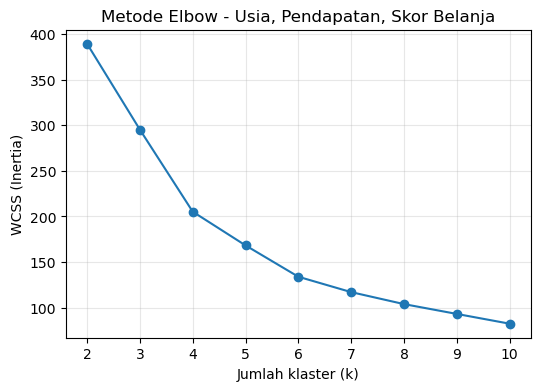

In [16]:
k_range = range(2, 11)
wcss3 = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X3_scaled)
    wcss3.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(k_range), wcss3, marker="o")
plt.xlabel("Jumlah klaster (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Metode Elbow - Usia, Pendapatan, Skor Belanja")
plt.grid(alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/elbow_3fitur.png", bbox_inches="tight")
plt.show()

Code ini digunakan untuk mencari jumlah cluster terbaik pada data yang menggunakan tiga fitur, yaitu usia, pendapatan tahunan, dan skor belanja. Algoritma K-Means dijalankan dengan jumlah cluster dari 2 sampai 10, kemudian nilai WCSS (Inertia) dihitung pada setiap percobaan. Hasil perhitungan ditampilkan dalam bentuk grafik Elbow Method dan disimpan sebagai file elbow_3fitur.png untuk digunakan pada laporan.

### 5. Silhouette Method (3 Fitur)

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

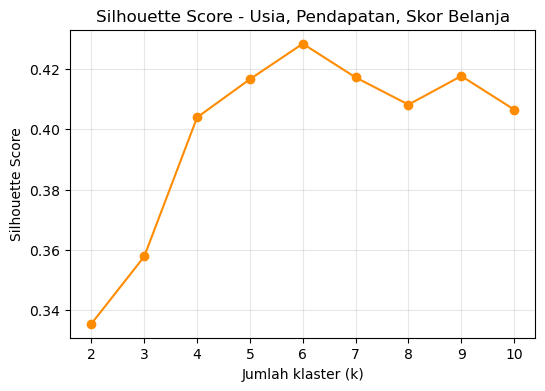

k= 2 | WCSS=  389.39 | Silhouette=0.3355
k= 3 | WCSS=  295.21 | Silhouette=0.3578
k= 4 | WCSS=  205.23 | Silhouette=0.4040
k= 5 | WCSS=  168.25 | Silhouette=0.4166
k= 6 | WCSS=  133.87 | Silhouette=0.4284
k= 7 | WCSS=  117.01 | Silhouette=0.4172
k= 8 | WCSS=  103.87 | Silhouette=0.4082
k= 9 | WCSS=   93.09 | Silhouette=0.4177
k=10 | WCSS=   82.39 | Silhouette=0.4066

 silhouette tertinggi: k = 6


In [21]:
sil3 = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X3_scaled)
    sil3.append(silhouette_score(X3_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(list(k_range), sil3, marker="o", color="darkorange")
plt.xlabel("Jumlah klaster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Usia, Pendapatan, Skor Belanja")
plt.grid(alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/silhouette_3fitur.png", bbox_inches="tight")
plt.show()

for k, w, s in zip(k_range, wcss3, sil3):
    print(f"k={k:2d} | WCSS={w:8.2f} | Silhouette={s:.4f}")

k_optimal_3d = list(k_range)[int(np.argmax(sil3))]
print(f"\n silhouette tertinggi: k = {k_optimal_3d}")

Code ini digunakan untuk menghitung Silhouette Score pada model yang menggunakan tiga fitur, yaitu usia, pendapatan tahunan, dan skor belanja. Algoritma K-Means dijalankan dengan jumlah cluster dari 2 sampai 10, kemudian nilai Silhouette dihitung untuk setiap percobaan. Hasilnya ditampilkan dalam bentuk grafik Silhouette Score dan disimpan sebagai file silhouette_3fitur.png. Setelah itu, program juga menampilkan nilai WCSS dan Silhouette Score untuk setiap jumlah cluster, lalu menentukan nilai k dengan Silhouette Score tertinggi sebagai jumlah cluster terbaik pada model tiga fitur.

### 6. Fit KMeans Final (3 Fitur) & Visualisasi 3D

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


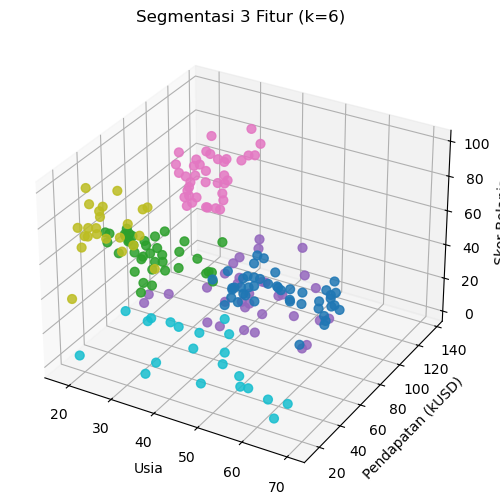

In [18]:
K_FINAL_3D = k_optimal_3d   # = 6
km3 = KMeans(n_clusters=K_FINAL_3D, n_init=10, random_state=RANDOM_STATE)
df["Cluster_3Fitur"] = km3.fit_predict(X3_scaled)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df["Usia"], df["Pendapatan_Tahunan_kUSD"], df["Skor_Belanja"],
           c=df["Cluster_3Fitur"], cmap="tab10", s=40, alpha=0.85)
ax.set_xlabel("Usia")
ax.set_ylabel("Pendapatan (kUSD)")
ax.set_zlabel("Skor Belanja")
ax.set_title(f"Segmentasi 3 Fitur (k={K_FINAL_3D})")
plt.savefig(f"{OUTPUT_DIR}/clusters_3fitur_3d.png", bbox_inches="tight")
plt.show()

Code ini digunakan untuk menjalankan algoritma K-Means dengan jumlah cluster terbaik pada model tiga fitur, yaitu 6 cluster. Setelah proses clustering selesai, hasil nomor cluster disimpan ke kolom Cluster_3Fitur pada dataset. Selanjutnya dibuat scatter plot 3 dimensi yang menampilkan hubungan antara usia, pendapatan tahunan, dan skor belanja, sehingga hasil pembagian cluster dapat terlihat lebih jelas. Grafik tersebut kemudian disimpan sebagai file clusters_3fitur_3d.png untuk digunakan pada laporan.

### 7. Bandingkan Profil Cluster: 2 Fitur vs 3 Fitur

In [19]:
ringkasan_3d = df.groupby("Cluster_3Fitur")[fitur_3d].mean().round(1)
ringkasan_3d = ringkasan_3d.rename(columns={
    "Usia": "Rata2_Usia",
    "Pendapatan_Tahunan_kUSD": "Rata2_Pendapatan",
    "Skor_Belanja": "Rata2_Skor_Belanja",
})
ringkasan_3d["Jumlah_Pelanggan"] = df.groupby("Cluster_3Fitur").size()
ringkasan_3d = ringkasan_3d.reset_index()
ringkasan_3d.to_csv(f"{OUTPUT_DIR}/ringkasan_segmen_3fitur.csv", index=False)
print("Profil cluster 3 FITUR:")
display(ringkasan_3d)

ringkasan_2d = df.groupby("Cluster_2Fitur")[fitur_2d].mean().round(1)
ringkasan_2d["Jumlah_Pelanggan"] = df.groupby("Cluster_2Fitur").size()
print("\n(Pembanding) Profil cluster 2 FITUR:")
display(ringkasan_2d.reset_index())

Profil cluster 3 FITUR:


,Cluster_3Fitur,Rata2_Usia,Rata2_Pendapatan,Rata2_Skor_Belanja,Jumlah_Pelanggan
0,0,56.3,54.3,49.1,45
1,1,26.8,57.1,48.1,39
2,2,41.9,88.9,17.0,33
3,3,32.7,86.5,82.1,39
4,4,25.0,25.3,77.6,23
5,5,45.5,26.3,19.4,21



(Pembanding) Profil cluster 2 FITUR:


,Cluster_2Fitur,Pendapatan_Tahunan_kUSD,Skor_Belanja,Jumlah_Pelanggan
0,0,55.3,49.5,81
1,1,86.5,82.1,39
2,2,25.7,79.4,22
3,3,88.2,17.1,35
4,4,26.3,20.9,23


Code ini digunakan untuk membuat ringkasan karakteristik setiap cluster pada model tiga fitur. Program menghitung rata-rata usia, pendapatan tahunan, dan skor belanja pada setiap cluster, kemudian menambahkan jumlah pelanggan di masing-masing cluster. Hasil ringkasan tersebut disimpan ke file ringkasan_segmen_3fitur.csv dan ditampilkan sebagai tabel. Setelah itu, program juga membuat ringkasan untuk model dua fitur agar hasil clustering dua fitur dan tiga fitur dapat dibandingkan dengan lebih mudah.

### 8. Jawaban Soal 3


> Jumlah klaster berubah dari 5 (menggunakan 2 fitur) menjadi 6 setelah fitur Usia ditambahkan. Ini menunjukkan bahwa usia ikut memengaruhi proses pengelompokan pelanggan. Pelanggan yang sebelumnya berada di klaster yang sama karena memiliki pendapatan dan skor belanja yang mirip, akhirnya terbagi ke klaster berbeda berdasarkan kelompok usianya.
>
> Menurut saya, segmentasi dengan 3 fitur lebih bermanfaat untuk pengelola pusat perbelanjaan karena memberikan informasi yang lebih lengkap. Dengan mengetahui usia, pengelola bisa menyesuaikan produk, promo, dan strategi pemasaran agar lebih sesuai dengan target pelanggan di setiap klaster.


---
# SOAL 4: Komposisi Gender Antar-Klaster

### 9. Crosstab Gender per Cluster

In [23]:
crosstab_count = pd.crosstab(df["Cluster_2Fitur"], df["Jenis_Kelamin"])
crosstab_pct = pd.crosstab(df["Cluster_2Fitur"], df["Jenis_Kelamin"], normalize="index") * 100

crosstab_count.to_csv(f"{OUTPUT_DIR}/komposisi_gender_per_cluster.csv")

print("Jumlah per gender tiap cluster:")
display(crosstab_count)
print("\nPersentase per gender stiap cluster:")
display(crosstab_pct.round(1))

Jumlah per gender tiap cluster:


Jenis_Kelamin,Laki-laki,Perempuan
Cluster_2Fitur,,
0,33,48
1,18,21
2,9,13
3,19,16
4,9,14



Persentase per gender stiap cluster:


Jenis_Kelamin,Laki-laki,Perempuan
Cluster_2Fitur,,
0,40.7,59.3
1,46.2,53.8
2,40.9,59.1
3,54.3,45.7
4,39.1,60.9


Code ini digunakan untuk melihat komposisi jenis kelamin pada setiap cluster hasil K-Means dua fitur. Program membuat tabel jumlah pelanggan laki-laki dan perempuan di setiap cluster, kemudian menghitung persentasenya berdasarkan jumlah pelanggan dalam masing-masing cluster. Hasil jumlah dan persentase tersebut ditampilkan sebagai tabel, lalu disimpan ke file komposisi_gender_per_cluster.csv untuk digunakan pada analisis dan laporan.

## 10.Independensi vs Cluster

In [26]:
chi2, p_value, dof, expected = chi2_contingency(crosstab_count)
print(f"chi2 = {chi2:.3f}, dof = {dof}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("p-value < 0.05: komposisi gender BERBEDA SIGNIFIKAN antar klaster.")
else:
    print("p-value >= 0.05: komposisi gender TIDAK berbeda signifikan antar klaster.")

chi2 = 2.232, dof = 4, p-value = 0.6932
p-value >= 0.05: komposisi gender TIDAK berbeda signifikan antar klaster.


Code ini digunakan untuk melakukan uji Chi-Square pada komposisi gender di setiap cluster. Program menghitung nilai Chi-Square, p-value, dan derajat kebebasan (degree of freedom) berdasarkan tabel komposisi gender yang sudah dibuat sebelumnya. Setelah itu, program membandingkan nilai p-value dengan batas 0,05 untuk menentukan apakah komposisi gender pada setiap cluster berbeda secara signifikan atau tidak. Hasil uji ini digunakan sebagai dasar kesimpulan pada analisis soal nomor 4.


### 11. Visualisasi Komposisi Gender

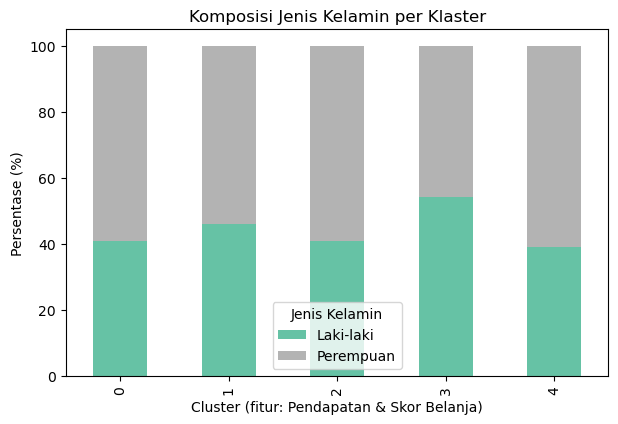

In [27]:
crosstab_pct.plot(kind="bar", stacked=True, figsize=(7,4.5), colormap="Set2")
plt.ylabel("Persentase (%)")
plt.xlabel("Cluster (fitur: Pendapatan & Skor Belanja)")
plt.title("Komposisi Jenis Kelamin per Klaster")
plt.legend(title="Jenis Kelamin")
plt.savefig(f"{OUTPUT_DIR}/komposisi_gender_per_cluster.png", bbox_inches="tight")
plt.show()

Code ini digunakan untuk membuat diagram batang bertumpuk (stacked bar chart) yang menampilkan persentase pelanggan laki-laki dan perempuan pada setiap cluster. Grafik ini memudahkan perbandingan komposisi gender antar cluster secara visual. Setelah grafik selesai dibuat, hasilnya disimpan sebagai file komposisi_gender_per_cluster.png dan ditampilkan pada notebook untuk digunakan dalam laporan.

## 12. Jawaban Soal No 4

**Bagian 1 - Apakah komposisi gender berbeda antar-klaster?**

erdasarkan hasil uji chi-square (p-value = 0,69, lebih besar dari 0,05), komposisi gender di setiap klaster tidak berbeda secara signifikan. Artinya, jumlah pelanggan laki-laki dan perempuan di tiap klaster relatif seimbang, jadi tidak ada klaster yang benar-benar didominasi oleh salah satu gender.

**Bagian 2 - Mengapa Jenis Kelamin sebaiknya tidak langsung dimasukkan ke K-Means tanpa encoding?**

K-Means menghitung jarak antar data menggunakan jarak Euclidean, jadi algoritma ini lebih cocok untuk data yang berupa angka. Sementara itu, Jenis Kelamin adalah data kategori, bukan angka yang punya urutan atau jarak tertentu.

Kalau gender langsung diubah menjadi angka, misal Laki-laki = 0 dan Perempuan = 1, K-means akan menganggap perbedaan angka tersebut punya artian jarak. Padahal angka itu cuma sebagai kode, bukan berarti satu gender “lebih besar” atau “lebih kecil” dari yang lain.

Selain itu, nilai pada fitur lain seperti Usia, Pendapatan Tahunan, dan Skor Belanja memiliki rentang yang jauh lebih besar dibanding gender yang hanya 0 dan 1. Akibatnya pengaruh gender bisa jadi sangat kecil atau malah tidak tepat jika semua fitur di-scale bersama.

Karena itu, gender lebih baik digunakan setelah proses clustering untuk melihat karakteristik atau profil setiap klaster, misalnya membandingkan jumlah laki-laki dan perempuan di masing-masing segmen.